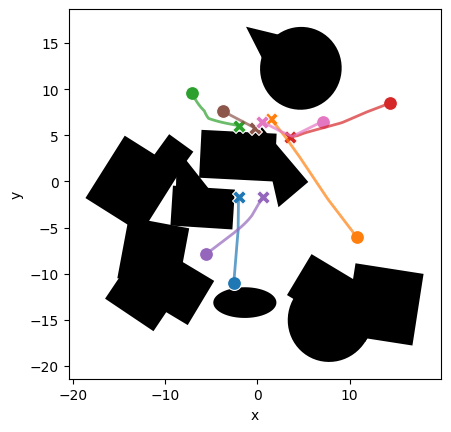

In [40]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

path = Path('data/ORCA/maps/scene_000000')

sim = np.load(path / 'sim.npz')
df_data = pd.DataFrame(
    sim['trackPos'].reshape(-1, 2),
    columns=['x', 'y'],
    index=pd.MultiIndex.from_product(
        [range(sim['numAgents']), range(len(sim['trackTime']))],
        names=['id', 'f']
    )
)
fps = 1 / np.diff(sim['trackTime']).mean()

with open(path / 'map.pkl', 'rb') as f:
    map_data = pickle.load(f)   

fig, ax = plt.subplots()
for polygen in map_data:
    polygon = plt.Polygon(polygen, closed=True, fill=True, edgecolor='none', facecolor='black', alpha=1.0)
    ax.add_patch(polygon)

for idx, (pid, group) in enumerate(df_data.sort_values(['id', 'f']).groupby('id')):
    color = sns.color_palette('tab10', n_colors=sim['numAgents'])[idx % sim['numAgents']]
    sns.lineplot( data=group, x='x', y='y', ax=ax, linewidth=2.0, alpha=0.7, legend=False, color=color )
    sns.scatterplot( data=group.iloc[[0]], x='x', y='y', ax=ax, s=100, alpha=1.0, legend=False, marker='o', color=color )
    sns.scatterplot( data=group.iloc[[-1]], x='x', y='y', ax=ax, s=100, alpha=1.0, legend=False, marker='X', color=color )

xy_list = np.array(sum(map_data, []))
xmin = xy_list[:, 0].min()
xmax = xy_list[:, 0].max()
ymin = xy_list[:, 1].min()
ymax = xy_list[:, 1].max()
scale_ratio = 0.05
xmin = xmin - (xmax - xmin) * scale_ratio
xmax = xmax + (xmax - xmin) * scale_ratio
ymin = ymin - (ymax - ymin) * scale_ratio
ymax = ymax + (ymax - ymin) * scale_ratio
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')

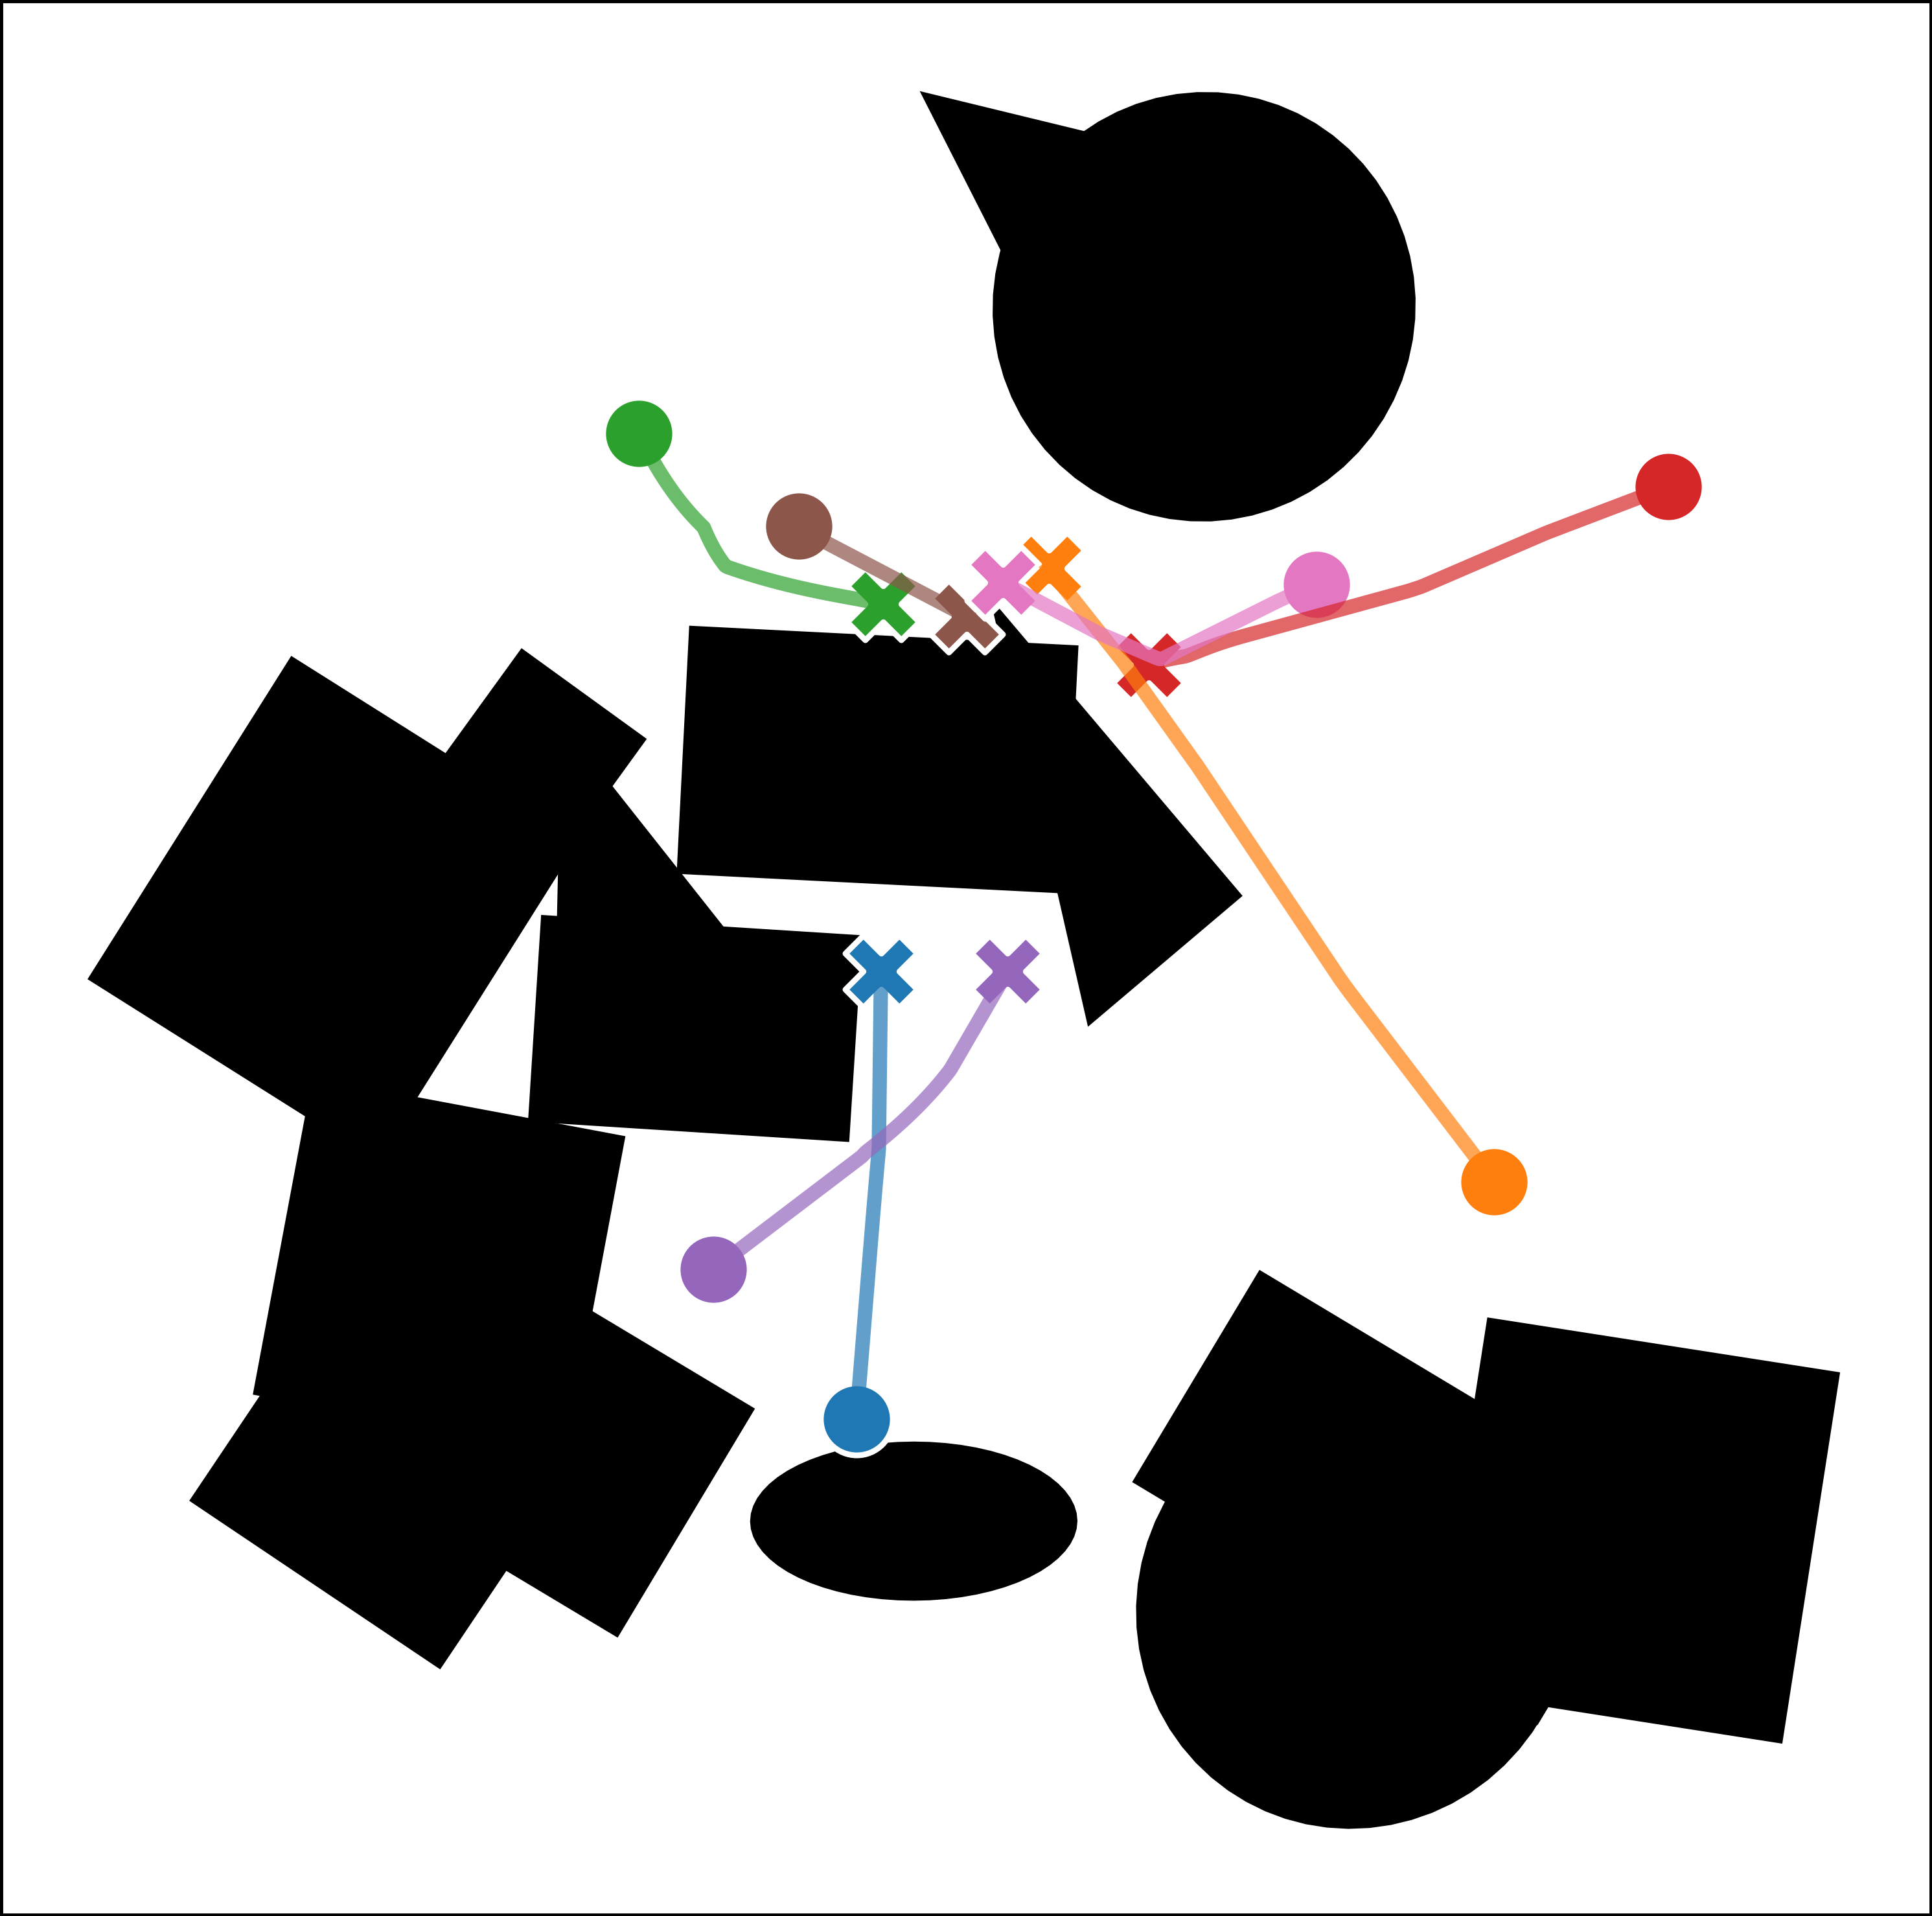

In [42]:
from PIL import Image

def crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=0, dpi=500):
    """
    从一个 matplotlib Axes 中裁剪指定数据区域，返回 PIL.Image。
    
    参数:
        ax: matplotlib.axes.Axes 对象
        xmin, xmax, ymin, ymax: 数据坐标范围
        pad_pixels: 裁剪时向内缩进像素，避免边线干扰
    
    返回:
        PIL.Image 对象
    """
    fig = ax.figure
    canvas = fig.canvas
    raw_dpi = ax.figure.dpi
    fig.set_dpi(dpi)   # 改变 Figure 的 DPI

    canvas.draw()  # 渲染 Figure
    argb = canvas.tostring_argb()
    w, h = canvas.get_width_height()

    # 坐标 -> 像素转换
    def data_to_pixel(xdata, ydata):
        px, py = ax.transData.transform(np.array([[xdata, ydata]]))[0]
        return int(round(px)), int(round(h - py))  # y 翻转
    
    pxmin, pymin = data_to_pixel(xmin, ymin)
    pxmax, pymax = data_to_pixel(xmax, ymax)

    fig.set_dpi(raw_dpi)  # 恢复原始 DPI

    # Figure 渲染成 RGBA 数组
    buf = np.frombuffer(argb, dtype=np.uint8)
    buf = buf.reshape(h, w, 4)
    buf = buf[:, :, [1, 2, 3, 0]]  # ARGB -> RGBA
    
    # 裁剪区域，加入 pad
    x0, x1 = sorted([pxmin, pxmax])
    y0, y1 = sorted([pymin, pymax])
    
    x0 += pad_pixels
    x1 -= pad_pixels
    y0 += pad_pixels
    y1 -= pad_pixels
    
    cropped = buf[y0:y1, x0:x1]
    return Image.fromarray(cropped)

# # ----------------------------
# # 示例用法
# x = np.linspace(0, 10, 100)
# y = np.sin(x)

# fig, ax = plt.subplots(dpi=100)
# ax.axis('equal')
# ax.plot(x, y, lw=1)

# # 红框仅作参考
# xmin, xmax, ymin, ymax = 2, 5, -0.5, 0.5
# ax.plot([xmin, xmax, xmax, xmin, xmin],
#         [ymin, ymin, ymax, ymax, ymin],
#         color='red', linewidth=0.5, antialiased=False)

crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=0, dpi=800)

In [48]:
from tqdm import tqdm

# dataset	name	path

df_list = []

for path in tqdm(sorted(Path('./data/ORCA/maps').glob('scene_*/'))):
    df_list.append({
        'dataset': 'ORCADataset',
        'name': f'maps-{path.name}',
        'path': str(path / 'data.csv.gz')
    })

for path in tqdm(sorted(Path('./data/ORCA/no_maps').glob('scene_*/'))):
    df_list.append({
        'dataset': 'ORCADataset',
        'name': f'no_maps-{path.name}',
        'path': str(path / 'data.csv.gz')
    })

df = pd.DataFrame(df_list)
df.to_csv('./data/datasets_ORCA.csv', index=False, sep='\t')

100%|██████████| 1000/1000 [00:00<00:00, 78064.06it/s]
